In [ ]:
import warnings
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

In [36]:
df = pd.read_csv("../Material/insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [37]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [38]:
dtypes = df.dtypes
dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [39]:
n_unique = df.nunique()
pd.DataFrame({"dtypes":dtypes, "Nunique": n_unique}).T

,age,sex,bmi,children,smoker,region,charges
dtypes,int64,str,float64,int64,str,str,float64
Nunique,47,2,548,6,2,4,1337


In [40]:
cat_cols = ['sex', 'children', 'smoker', 'region' ]
df[cat_cols] = df[cat_cols].astype("category")

In [41]:
pd.DataFrame(df.dtypes).T

,age,sex,bmi,children,smoker,region,charges
0,int64,category,float64,category,category,category,float64


In [42]:
pd. DataFrame(df.isnull().sum()).T

,age,sex,bmi,children,smoker,region,charges
0,0,0,0,0,0,0,0


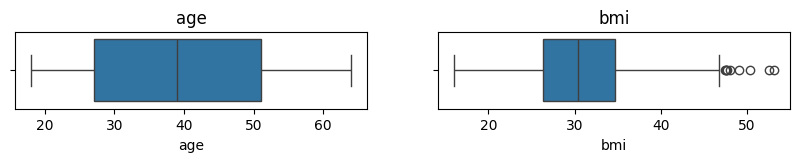

In [43]:
num_cols = ['age', 'bmi' ]
plt.figure(figsize=(10,1))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2,i+1)
    plt.title(f"{col}")
    sns.boxplot(df[col], orient='h')
plt. show()

In [44]:
Q1 = df.bmi.quantile(0.25)
Q3 = df.bmi.quantile(.75)
IQR = Q3 - Q1
upper = Q3 + 1.5*IQR
outliers= df[df.bmi>upper].bmi.values
df.bmi.replace(outliers, upper, inplace=True)

0       27.900
1       33.770
2       33.000
3       22.705
4       28.880
         ...  
1333    30.970
1334    31.920
1335    36.850
1336    25.800
1337    29.070
Name: bmi, Length: 1338, dtype: float64

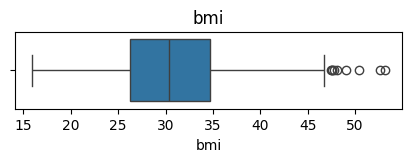

In [45]:
plt.figure(figsize=(5,1))
plt.title("bmi")
sns.boxplot(df.bmi, orient='h')
plt.show()

In [46]:
num_cols = ['age', 'bmi' ]
cat_cols = ['sex' ,'children' ,'smoker' , 'region' ]

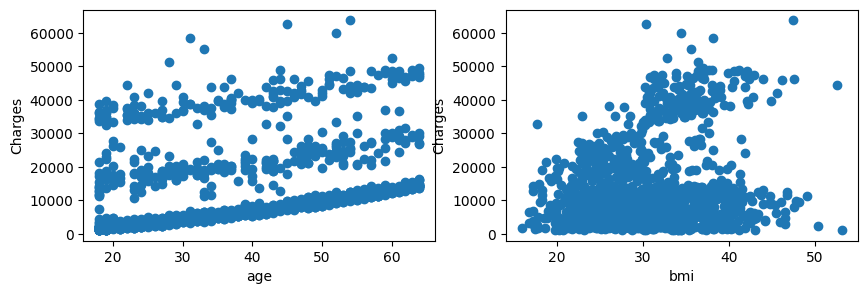

In [47]:
plt.figure(figsize=(10,3))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i+1)
    plt.xlabel(f"{col}")
    plt.ylabel(f"Charges")
    plt.scatter(df[col], df.charges)
plt.show()

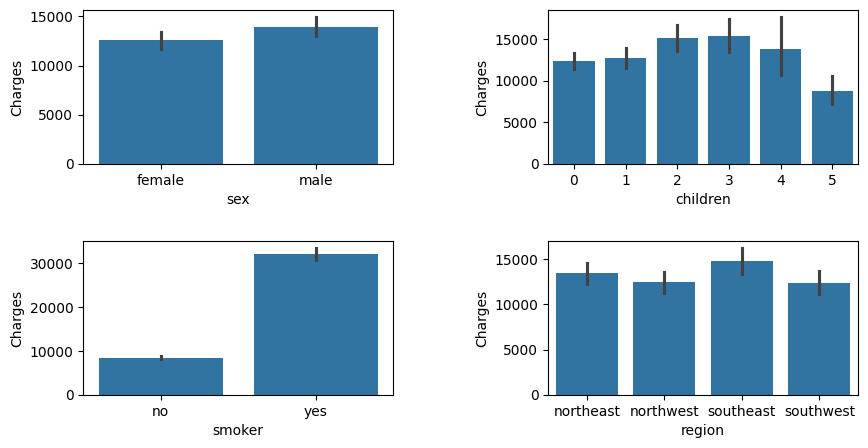

In [48]:
plt.figure(figsize=(10,5))
for i ,col in enumerate(cat_cols):
    plt.subplot(2, 2, i+1)
    plt.xlabel(f"{col}")
    plt.ylabel("Charges")
    sns.barplot(x = col, y= "charges", data = df)
plt.subplots_adjust(hspace =.5, wspace =.5)
plt.show()

In [49]:
df.duplicated().sum()

np.int64(1)

In [50]:
df.drop_duplicates(keep ="first", inplace = True)
df.duplicated().sum()

np.int64(0)

In [51]:
x = df.iloc[ : , : -1]
y = df. iloc[ : , -1: ]

In [52]:
x

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest
1334,18,female,31.920,0,no,northeast
1335,18,female,36.850,0,no,southeast
1336,21,female,25.800,0,no,southwest


In [53]:
y

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1333,10600.54830
1334,2205.98080
1335,1629.83350
1336,2007.94500


In [54]:
from category_encoders import OrdinalEncoder
cols_to_encode = ['sex', 'smoker' ]
ordinal_encoder = OrdinalEncoder(cols=cols_to_encode)
x = ordinal_encoder.fit_transform(x)

In [55]:
from category_encoders import OneHotEncoder
encoder = OneHotEncoder(cols=["region"])
x = encoder.fit_transform(x)

In [56]:
x

,age,sex,bmi,children,smoker,region_1,region_2,region_3,region_4
0,19,1,27.900,0,1,1,0,0,0
1,18,2,33.770,1,2,0,1,0,0
2,28,2,33.000,3,2,0,1,0,0
3,33,2,22.705,0,2,0,0,1,0
4,32,2,28.880,0,2,0,0,1,0
...,...,...,...,...,...,...,...,...,...
1333,50,2,30.970,3,2,0,0,1,0
1334,18,1,31.920,0,2,0,0,0,1
1335,18,1,36.850,0,2,0,1,0,0
1336,21,1,25.800,0,2,1,0,0,0
